# **Data Cleaning**

## Objectives

* Apply data validation and cleaning to remove invalid records and prevent data leakage

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Outputs

* Generate cleaned dataset for analysis saved as outputs/datasets/cleaned/HotelBookingsClean.csv
* Generate a valid dataset for the cleaning and engineering pipeline to correct saved as outputs/datasets/cleaned/HotelBookingsValid.csv

## Decisions from Revenue Manager

* Duplicate bookings should remain in place
* Bookings with no guests (adults, children or babies) should be removed
* Values > 4 for babies or children and > 2 for car park spaces should be replaced with their column's median value
* Bookings with >= 5 adults should be removed
* Isolated high and low outliers for adr should be removed
* Missing data in children should be replaced by 0
* Missing data in agent and company should be replaced by 0
* Missing data in country should be replaced by the mode value 

## Standard data cleaning

* Drop variables: `['reservation_status', 'reservation_status_date']`
* Perform dtype correction on children, agent and company (float -> int)
* Ensure all numeric-as-categorical features (except target) are converted to 'category'
* Resolve "Undefined" rows in meal, market_segment and distribution_channel


---

## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir


'/home/niall/PP4/cancel-protect'

## Load Data

In [3]:
import pandas as pd
df_raw = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df_raw.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


---

## Outliers

1. Bookings with no guests of any description should be removed. This are impossible bookings and as such are a data validity issue and should be executed fully in the notebook.

In [4]:
df_raw.shape

(119390, 32)

In [5]:
no_guest_df = df_raw[((df_raw["adults"] == 0) & (df_raw["children"] == 0) & (df_raw["babies"] == 0))]
no_guest_df.shape

(180, 32)

In [6]:
df_valid = df_raw.drop(no_guest_df.index)
df_valid.shape

(119210, 32)

2. Bookings with 5 or more adults should be removed. These are also 'impossible bookings' and should be removed.

In [7]:
many_adults_df = df_valid[df_valid["adults"] >= 5]
many_adults_df.shape

(16, 32)

In [8]:
df_valid = df_valid.drop(many_adults_df.index)
df_valid.shape

(119194, 32)

3. Bookings with more than 4 babies or children and bookings with more than 2 car park spaces should be removed. Another case of very rare 'impossible bookings' to be handled in the notebook not the pipeline

In [9]:
high_values_df = df_valid[((df_valid["children"] > 4) | (df_valid["babies"] > 4) | (df_valid["required_car_parking_spaces"] > 2))]
high_values_df               

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
328,Resort Hotel,1,55,2015,July,29,12,4,10,2,...,No Deposit,8.0,NaN,0,Contract,133.16,0,1,No-Show,2015-07-12
29045,Resort Hotel,0,26,2017,March,11,14,0,5,2,...,No Deposit,NaN,NaN,0,Transient-Party,40.00,8,1,Check-Out,2017-03-19
29046,Resort Hotel,0,138,2017,March,12,19,2,2,2,...,No Deposit,NaN,NaN,122,Transient-Party,80.00,8,0,Check-Out,2017-03-23
38117,Resort Hotel,0,205,2017,June,26,26,3,10,2,...,No Deposit,250.0,NaN,0,Transient,111.00,3,0,Check-Out,2017-07-09
46619,City Hotel,0,37,2016,January,3,12,0,2,2,...,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14
78656,City Hotel,0,11,2015,October,42,11,2,1,1,...,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14
102762,City Hotel,0,13,2016,December,50,5,1,0,1,...,No Deposit,9.0,NaN,0,Transient,96.00,3,0,Check-Out,2016-12-06
110812,City Hotel,0,30,2017,April,17,29,2,1,2,...,No Deposit,9.0,NaN,0,Transient-Party,153.33,3,2,Check-Out,2017-05-02


In [10]:
df_valid = df_valid.drop(high_values_df.index)


In [11]:
df_valid.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


* Re-run high values check to ensure changes have taken effect

In [12]:
high_values_df = df_valid[((df_valid["children"] > 4) | (df_valid["babies"] > 4) | (df_valid["required_car_parking_spaces"] > 2))]
high_values_df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


4. Remove negative values for `adr`

In [13]:
df_raw["adr"].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

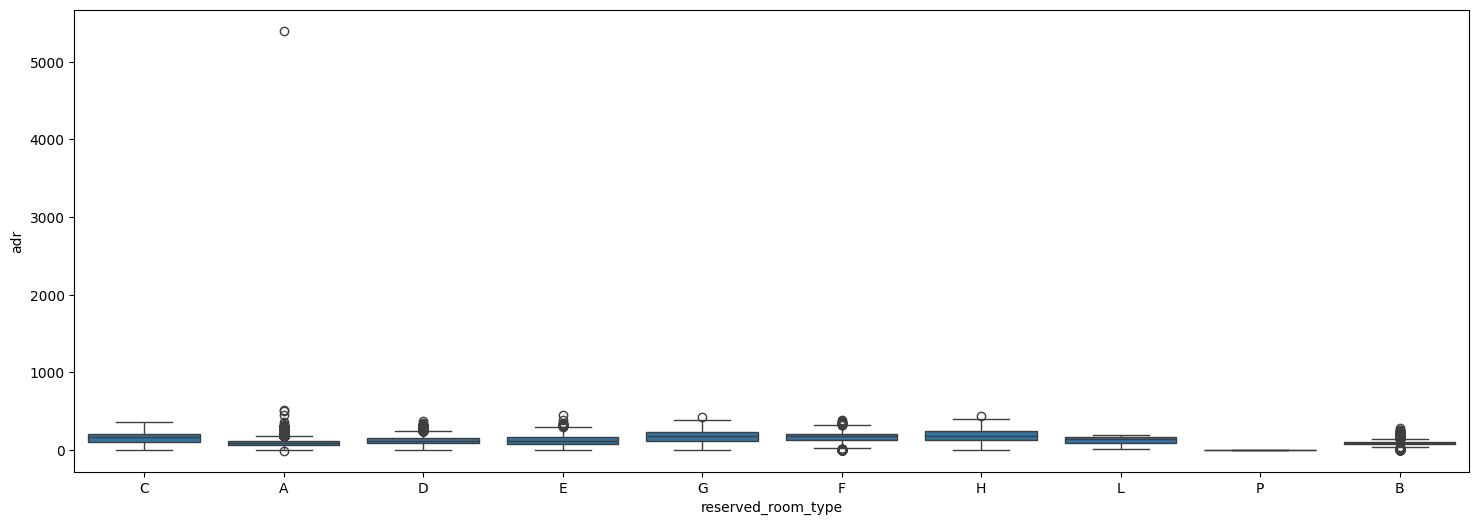

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(18, 6))
sns.boxplot(data=df_raw,
                x="reserved_room_type",
                y="adr",
                ax=ax)

plt.show()

* We can see from the chart that only one value exceeds 1000 for adr, we will handle this outlier in the pipeline, but remve from the clean eda dataset later in this notebook.

In [15]:
negative_adr = df_valid[(df_valid["adr"] < 0)]
negative_adr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [16]:
df_valid = df_valid.drop(negative_adr.index)
df_valid["adr"].describe()

count    119185.000000
mean        101.983881
std          50.423779
min           0.000000
25%          69.520000
50%          94.970000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

---

## Drop data leakage columns

Since the model is intended to run on live hotel data, it should not be trained on any data only available *after* the booking's resolution. Two columns here provide data that is not available on live data: `reservation_status` and `reservation_status_date`.

* These 2 variables should be dropped

In [17]:
df_valid = df_valid.drop(columns=["reservation_status", "reservation_status_date"])
df_valid.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1


---

## Rows with "Undefined" values

In [18]:
cols = ["meal", "market_segment", "distribution_channel"]
undefined_rows = df_valid[df_valid[cols].isin(["Undefined"]).any(axis=1)]
undefined_rows.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
3106,Resort Hotel,0,105,2015,November,47,18,2,4,2,...,A,0,No Deposit,313.0,NaN,65,Transient-Party,69.0,0,0
3107,Resort Hotel,0,105,2015,November,47,18,2,4,2,...,A,0,No Deposit,313.0,NaN,65,Transient-Party,69.0,0,0
3108,Resort Hotel,0,105,2015,November,47,18,2,4,2,...,A,0,No Deposit,313.0,NaN,65,Transient-Party,69.0,0,0
3110,Resort Hotel,0,62,2015,November,47,18,2,4,2,...,A,0,No Deposit,313.0,NaN,0,Transient-Party,69.0,0,0
3111,Resort Hotel,0,105,2015,November,47,18,2,4,2,...,A,0,No Deposit,313.0,NaN,65,Transient-Party,69.0,0,0


In [19]:
undefined_rows.shape

(1174, 30)

* Over the 3 variables, there are 1174 rows to remove totalling less than 1% of the data

In [20]:
undefined_counts = df_valid[cols].apply(lambda x: (x == "Undefined").sum())
undefined_counts

meal                    1169
market_segment             2
distribution_channel       5
dtype: int64

In [21]:
undefined_counts.sum()

np.int64(1176)

* The majority of the rows are from the `meal` column and since the total of undefined value counts exceeds the total number of affected rows, we must conclude that some rows have undefined in more than one variable.

In [22]:
df_valid["meal"].value_counts()

meal
BB           92217
HB           14453
SC           10548
Undefined     1169
FB             798
Name: count, dtype: int64

* Since the descriptive notes on the dataset state "Undefined/SC – no meal package", the appropriate method for handling the meal rows is to replace "Undefined" with "SC". This step belongs in the pre-processing pipeline.

In [23]:
df_clean = df_valid.copy()

df_clean["meal"] = df_clean["meal"].replace("Undefined", "SC")
df_clean["meal"].value_counts()

meal
BB    92217
HB    14453
SC    11717
FB      798
Name: count, dtype: int64

In [24]:
undefined_rows = df_clean[df_clean.isin(["Undefined"]).any(axis=1)]
undefined_rows.shape

(5, 30)

* These rows can now be dropped from the valid dataset and the fully cleaned dataset

In [25]:
df_clean = df_clean.drop(undefined_rows.index)
df_valid = df_valid.drop(undefined_rows.index)

In [26]:
undefined_rows = df_clean[df_clean.isin(["Undefined"]).any(axis=1)]
undefined_rows

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests


In [27]:
undefined_valid = df_valid[df_valid.isin(["Undefined"]).any(axis=1)]
undefined_valid.shape

(1169, 30)

---

### High adr value

In [ ]:
df_clean = df_clean.drop(df_valid[((df_valid["adr"] > 1000))].index)
df_clean[""]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0


### Missingness

* Missing values imputation is a pipeline action so these corrections should only be saved to the fully cleaned dataset for analysis only purposes

In [ ]:
# The following function is adapted from the 'Churnometer' walkthrough
def evaluate_missing_data(df):
    missing_data_absolute = df.isnull().sum()
    missing_data_percentage = round(missing_data_absolute/len(df)*100, 2)
    df_missing_data = (pd.DataFrame(
                            data={"RowsWithMissingData": missing_data_absolute,
                                   "PercentageOfDataset": missing_data_percentage,
                                   "DataType": df.dtypes}
                                    )
                          .sort_values(by=['PercentageOfDataset'], ascending=False)
                          .query("RowsWithMissingData > 0")
                          )

    return df_missing_data

In [ ]:
evaluate_missing_data(df_clean)

* As per received guidance [Revenue Manager's Notebook](/jupyter_notebooks/03_rm_analysis.ipynb), replace missing values in `children`, `agent` and `company` with '0'

* The rows with missing children have been removed in a prior cleaning step.

* Check that 0 is not in use for `agent` or `company`

In [ ]:
df_raw[["company", "agent"]].describe()

* The minimum values confirm that 0 is not present in the existing values

In [ ]:
def replace_zeros(df):
    cols_to_replace_zero = ["children", "company", "agent"]
    for col in cols_to_replace_zero:
        df_clean[col] = df_clean[col].fillna(0)
    return df_clean    

replace_zeros(df_clean)

In [ ]:
df_clean.head(10)

In [ ]:
evaluate_missing_data(df_clean)

* For `country` we should replace the missing values with the variable mode value

In [ ]:
df_raw["country"].mode()

* Replace missing values with "PRT" and re-evaluate missingness

In [ ]:
df_clean["country"] = df_clean["country"].fillna("PRT")
evaluate_missing_data(df_clean)

## Type Conversions

1. Children float64 should be int64 since partial children are not possible

In [ ]:
df_clean["children"].dtypes

In [ ]:
df_clean["children"] = df_clean["children"].astype("int64")
df_clean["children"].dtypes

2. Numeric-as-categoric conversion

In [ ]:
df_clean.dtypes

* Convert `is_repeated_guest`, `agent` and `company` to categorical features 

In [ ]:
# First replace float64 dtypes with int64
float_list = ["agent", "company"]
for col in float_list:
    df_clean[col] = df_clean[col].astype("int64")

df_clean.info()

In [ ]:
categorical_list = ["is_repeated_guest", "agent", "company"]
for col in categorical_list:
    df_clean[col] = df_clean[col].astype("category")

df_clean.info()

* `is_canceled` is kept as numeric because the point-biserial correlation in the [correlation study](/jupyter_notebooks/05_correlation_study.ipynb) requires a numeric binary target
* `arrival_date_year` and `arrival_date_day_of_month` are kept as numeric for datetime amalgamation in [feature engineering](/jupyter_notebooks/06_feature_engineering.ipynb)
* `arrival_date_week_number` is kept as numeric due to its cyclical nature, a full categorisation can be performed in [feature engineering](/jupyter_notebooks/06_feature_engineering.ipynb)

# Push files to Repo

* Save the cleaned dataframe for future use

In [ ]:
try:
  os.makedirs(name='outputs/datasets/cleaned')
except Exception as e:
  print(e)


In [ ]:
df_clean.to_csv("outputs/datasets/cleaned/HotelBookingsClean.csv", index=False)
df_valid.to_csv("outputs/datasets/cleaned/HotelBookingsValid.csv", index=False)

---

## Conclusions

* Compare cleaned dataset to original

In [ ]:
df_raw = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df_raw.info()

In [ ]:
print(f"Original dataset had shape: {df_raw.shape}.")
print(f"Valid dataset has shape: {df_valid.shape}.")
print(f"Clean dataset has shape: {df_clean.shape}.")

* Original dataset (119,390 rows) was processed into two outputs:
    * HotelBookingsValid.csv – a data-valid dataset retaining missing values and documented placeholder values for preprocessing within the modelling pipeline.
    * HotelBookingsClean.csv – a fully cleaned dataset for exploratory analysis, statistical testing and feature engineering.
* Removed invalid records that could not represent genuine bookings, including bookings with no guests, implausible guest counts, excessive children/babies/car parking requests and negative ADR values.
* Both datasets now have the shape: (119180, 30), saved to outputs/datasets/cleaned/HotelBookingsClean.csv and outputs/datasets/cleaned/HotelBookings/Valid

**Next Steps**
* The cleaned dataset is ready for the [Correlation Study](/jupyter_notebooks/05_correlation_study.ipynb), which will assess relationships between features and `is_canceled`
* The valid dataset is ready for the preprocessing pipeling in [feature engineering](/jupyter_notebooks/07_feature_engineering.ipynb)